# Time series Practice

In [87]:
import pandas as pd
import numpy as np

In [88]:
df = pd.read_csv('date_data.csv')

In [89]:
df

,Date,Product,Sales
0,2024-01-01,A,100
1,2024-01-02,A,110
2,2024-01-03,A,120
3,2024-01-04,A,130
4,2024-01-05,A,90
5,2024-01-06,A,80
6,2024-01-07,A,150
7,2024-01-08,A,160
8,2024-01-09,A,170
9,2024-01-10,A,200


In [90]:
df.dtypes

Date       object
Product    object
Sales       int64
dtype: object

In [91]:
df['Date'] = pd.to_datetime(df['Date'])

In [92]:
df.groupby('Product')['Sales'].rolling(3).mean().reset_index(level=0, drop=True)

0            NaN
1            NaN
2     110.000000
3     120.000000
4     113.333333
5     100.000000
6     106.666667
7     130.000000
8     160.000000
9     176.666667
10           NaN
11           NaN
12    200.000000
13    206.666667
14    213.333333
15    230.000000
16    240.000000
17    250.000000
18    260.000000
19    276.666667
Name: Sales, dtype: float64

In [93]:
df['rolling_avg_7_days'] = df.groupby('Product')['Sales'].transform(lambda x: x.rolling(7).mean())

In [94]:
df

,Date,Product,Sales,rolling_avg_7_days
0,2024-01-01,A,100,NaN
1,2024-01-02,A,110,NaN
2,2024-01-03,A,120,NaN
3,2024-01-04,A,130,NaN
4,2024-01-05,A,90,NaN
5,2024-01-06,A,80,NaN
6,2024-01-07,A,150,111.428571
7,2024-01-08,A,160,120.000000
8,2024-01-09,A,170,128.571429
9,2024-01-10,A,200,140.000000


In [95]:
df.set_index('Date').groupby('Product').resample('W')['Sales'].sum()

Product  Date      
A        2024-01-07     780
         2024-01-14     530
B        2024-01-07    1540
         2024-01-14     830
Name: Sales, dtype: int64

In [96]:
df.groupby('Product').resample('W', on='Date')['Sales'].sum()

Product  Date      
A        2024-01-07     780
         2024-01-14     530
B        2024-01-07    1540
         2024-01-14     830
Name: Sales, dtype: int64

In [97]:
df.groupby("Product").resample("W", on='Date')['Sales'].mean()

Product  Date      
A        2024-01-07    111.428571
         2024-01-14    176.666667
B        2024-01-07    220.000000
         2024-01-14    276.666667
Name: Sales, dtype: float64

In [98]:
df.groupby('Product').resample('W', on='Date').count()

Product  Sales  rolling_avg_7_days
Product Date                                          
A       2024-01-07        7      7                   1
        2024-01-14        3      3                   3
B       2024-01-07        7      7                   1
        2024-01-14        3      3                   3

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

In [101]:
df

,Date,Product,Sales,rolling_avg_7_days
0,2024-01-01,A,100,NaN
1,2024-01-02,A,110,NaN
2,2024-01-03,A,120,NaN
3,2024-01-04,A,130,NaN
4,2024-01-05,A,90,NaN
5,2024-01-06,A,80,NaN
6,2024-01-07,A,150,111.428571
7,2024-01-08,A,160,120.000000
8,2024-01-09,A,170,128.571429
9,2024-01-10,A,200,140.000000


<Axes: xlabel='Date', ylabel='Sales'>

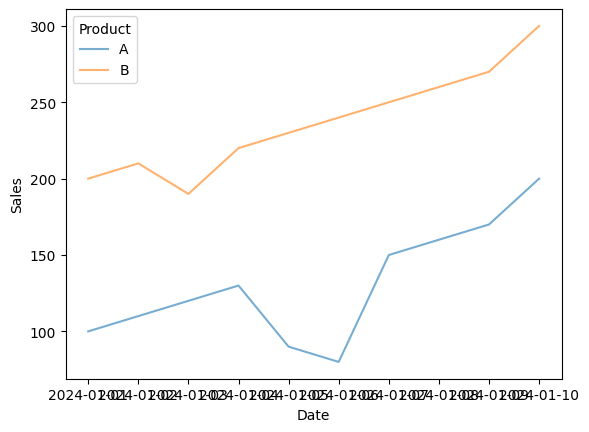

In [103]:
sns.lineplot(data=df, x='Date', y='Sales', hue='Product', legend='brief', alpha=0.6)

<Axes: xlabel='Date', ylabel='rolling_avg_7_days'>

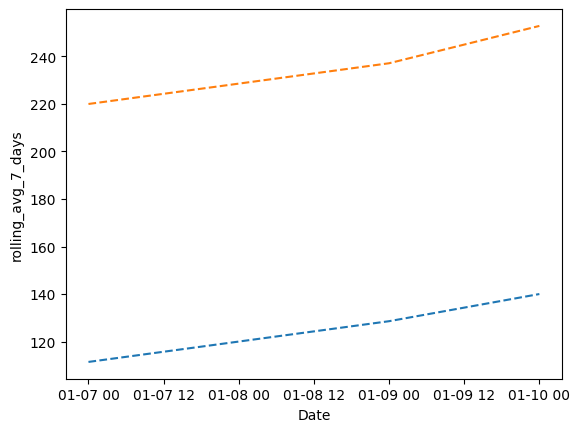

In [104]:
sns.lineplot(data=df, x='Date', y='rolling_avg_7_days', hue='Product', legend=False, linestyle='--')

In [ ]:
df[(df['Product'] == 'A') ].sort_values(by='Sales', ascending=False).head(1)

,Date,Product,Sales,rolling_avg_7_days
9,2024-01-10,A,200,140.0


In [ ]:
df = pd.read_csv('resample.csv')

In [ ]:
df

,Timestamp,Product,Sales
0,2024-01-01 01:00,A,100
1,2024-01-01 02:00,A,120
2,2024-01-01 03:00,B,90
3,2024-01-01 04:00,B,150
4,2024-01-02 01:00,A,110
5,2024-01-02 02:00,B,140
6,2024-01-03 03:00,A,160
7,2024-01-03 05:00,B,180
8,2024-02-01 01:00,A,130
9,2024-02-01 04:00,B,170


In [ ]:
df.dtypes

Timestamp    object
Product      object
Sales         int64
dtype: object

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
df

,Timestamp,Product,Sales
0,2024-01-01 01:00:00,A,100
1,2024-01-01 02:00:00,A,120
2,2024-01-01 03:00:00,B,90
3,2024-01-01 04:00:00,B,150
4,2024-01-02 01:00:00,A,110
5,2024-01-02 02:00:00,B,140
6,2024-01-03 03:00:00,A,160
7,2024-01-03 05:00:00,B,180
8,2024-02-01 01:00:00,A,130
9,2024-02-01 04:00:00,B,170


In [ ]:
df.groupby('Product').resample('D', on='Timestamp')['Sales'].sum().reset_index()

,Product,Timestamp,Sales
0,A,2024-01-01,220
1,A,2024-01-02,110
2,A,2024-01-03,160
3,A,2024-01-04,0
4,A,2024-01-05,0
...,...,...,...
62,B,2024-01-30,0
63,B,2024-01-31,0
64,B,2024-02-01,170
65,B,2024-02-02,0


In [ ]:
df.set_index('Timestamp').groupby('Product').resample('W')['Sales'].sum()

Product  Timestamp 
A        2024-01-07    490
         2024-01-14      0
         2024-01-21      0
         2024-01-28      0
         2024-02-04    320
B        2024-01-07    560
         2024-01-14      0
         2024-01-21      0
         2024-01-28      0
         2024-02-04    370
Name: Sales, dtype: int64

In [ ]:
df.groupby('Product').resample('ME', on='Timestamp')['Sales'].max()

Product  Timestamp 
A        2024-01-31    160
         2024-02-29    190
B        2024-01-31    180
         2024-02-29    200
Name: Sales, dtype: int64

In [ ]:
df.groupby('Product')['Sales'].rolling(3).mean().reset_index()

,Product,level_1,Sales
0,A,0,NaN
1,A,1,NaN
2,A,4,110.000000
3,A,6,130.000000
4,A,8,133.333333
5,A,10,160.000000
6,B,2,NaN
7,B,3,NaN
8,B,5,126.666667
9,B,7,156.666667


<Axes: xlabel='Timestamp', ylabel='Sales'>

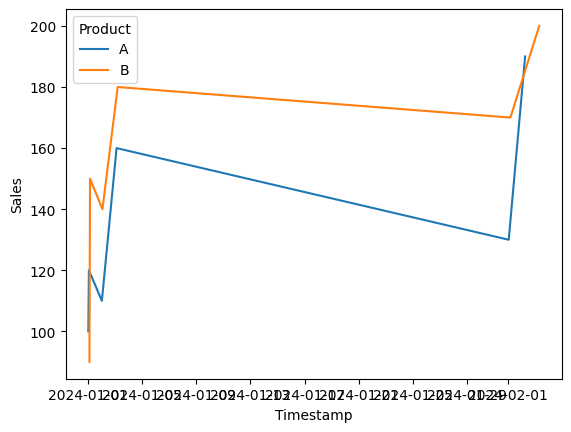

In [ ]:
sns.lineplot(df, x='Timestamp', y='Sales', hue='Product')

<Axes: xlabel='Timestamp'>

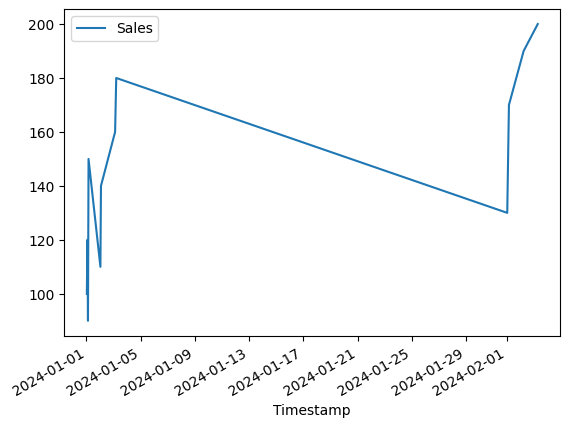

In [ ]:
df.plot(kind='line', x='Timestamp', y='Sales')